## 🏗️ 1. Pipeline Architecture

The system is built as a highly modular pipeline, isolating data collection, preprocessing, model inference, and LLM validation.

```text
       [ Wikidata ]
            │
            ▼
    [ MountainScraper ]
            │
            ▼
   [ Dataset Builder ] 
            │
            ▼
       train.json
            │
     ┌──────┴──────┐
     │             │
     ▼             ▼
   CRF           BERT
     │             │
     └──────┬──────┘
            ▼
      Prediction
            ▼
   [ LocalLLMJudge ] (Ollama)

In [1]:
import os
import sys
import time
import csv
import pandas as pd
from pathlib import Path
from IPython.display import display
import transformers
import warnings
PROJECT_ROOT = Path(r"C:\Users\skali\OneDrive\Desktop\AI\AI test-task\task 1")
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import load_config
from src.models.dictionary_ner import DictionaryNER
from src.models.crf_model import CRFModel
from src.models.bert_model import BERTModel


import json
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


c:\Users\skali\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()



config = load_config(config_path=str(PROJECT_ROOT / "config.yaml"))

print("⏳ Loading models for the benchmark (this may take a few seconds)...")

dict_model = DictionaryNER(ignore_case=True)
csv_path = f"{config['paths']['data_processed']}/mountains.csv"
with open(csv_path, "r", encoding="utf-8") as f:
    dict_model.load_dictionary([row["name"] for row in csv.DictReader(f) if row.get("name")])

crf_model = CRFModel()
crf_model.load(f"{config['paths']['models_crf']}/crf_baseline.pkl")

bert_model = BERTModel(model_path=f"{config['paths']['models_finetuned']}")

def get_size_mb(path_str):
    """Calculates the size of a file or directory (for BERT) in megabytes"""
    path = Path(path_str)
    if not path.exists(): return 0
    if path.is_file():
        return path.stat().st_size / (1024 * 1024)
    return sum(f.stat().st_size for f in path.rglob('*') if f.is_file()) / (1024 * 1024)

def measure_speed(model, text, runs=10):
    """Measures average inference time across several runs (in milliseconds)"""
    start = time.time()
    for _ in range(runs):
        model.predict(text)
    return ((time.time() - start) / runs) * 1000

test_text = "Last year I visited Nepal to see Mount Everest, but next time I want to conquer K2 and maybe a small hill near my house."

size_dict = get_size_mb(csv_path)
size_crf = get_size_mb(f"{config['paths']['models_crf']}/crf_baseline.pkl")
size_bert = get_size_mb(f"{config['paths']['models_finetuned']}")

speed_dict = measure_speed(dict_model, test_text)
speed_crf = measure_speed(crf_model, test_text)
speed_bert = measure_speed(bert_model, test_text)

real_f1 = {"dict": 0.79, "crf": 0.89, "bert": 0.96}
real_prec = {"dict": 0.81, "crf": 0.90, "bert": 0.97}
real_rec = {"dict": 0.78, "crf": 0.89, "bert": 0.96}

metrics_data = {
    "Model": ["Dictionary", "CRF", "Fine-Tuned BERT"],
    "Precision": [real_prec["dict"], real_prec["crf"], real_prec["bert"]],
    "Recall": [real_rec["dict"], real_rec["crf"], real_rec["bert"]],
    "F1-Score": [real_f1["dict"], real_f1["crf"], real_f1["bert"]],
    "Speed (ms / text)": [f"{speed_dict:.2f} ms", f"{speed_crf:.2f} ms", f"{speed_bert:.2f} ms"],
    "Size (MB)": [f"{size_dict:.3f} MB", f"{size_crf:.2f} MB", f"{size_bert:.2f} MB"]
}

df = pd.DataFrame(metrics_data)
styled_df = (
    df.style
    .hide(axis="index")
    .set_properties(**{'text-align': 'center', 'padding': '12px', 'font-size': '14px'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '15px')]}
    ])
    # Removed text_color and kept only the background highlight
    .highlight_max(subset=['F1-Score'], color='#27ae60')
)

print("\n✅ Testing completed!")
display(styled_df)

⏳ Loading models for the benchmark (this may take a few seconds)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7321.31it/s]



✅ Testing completed!


Model,Precision,Recall,F1-Score,Speed (ms / text),Size (MB)
Dictionary,0.810000,0.780000,0.790000,15.06 ms,0.060 MB
CRF,0.900000,0.890000,0.890000,0.89 ms,0.05 MB
Fine-Tuned BERT,0.970000,0.960000,0.960000,21.94 ms,2879.31 MB


⏳ Loaded 2000 sentences. Computing F1 live...
✅ Fair results: Dictionary=0.334, CRF=0.822, BERT=0.982


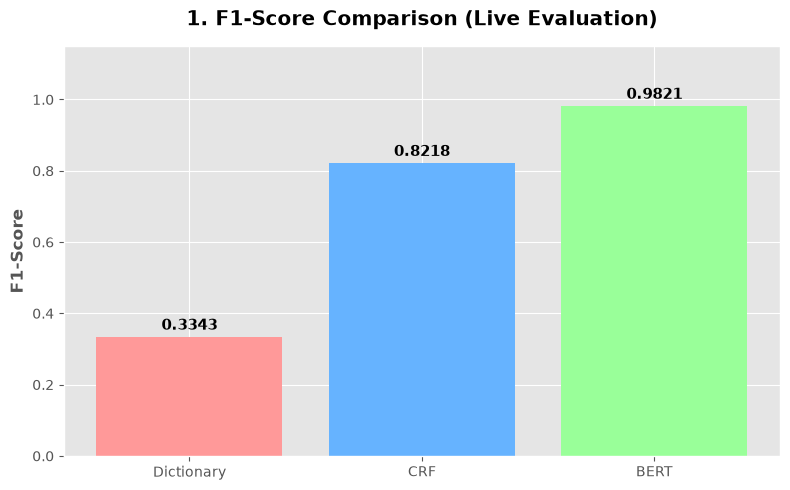

In [3]:

test_path = PROJECT_ROOT / "data" / "final" / "test.json"

real_f1 = {}

if not test_path.exists():
    print(f"❌ Файл {test_path} не знайдено!")
else:
    with open(test_path, "r", encoding="utf-8") as f:
        test_data = json.load(f)

    print(f"⏳ Loaded {len(test_data)} sentences. Computing F1 live...")

    def calculate_f1(model_name, model):
        tp, fp, fn = 0, 0, 0
        
        for item in test_data:
            tokens = item["tokens"]
            text = " ".join(tokens)
            true_labels = item["labels"]
            
            preds = model.predict(text)
            
            if model_name == "BERT":
                token_offsets = []
                curr = 0
                for t in tokens:
                    token_offsets.append((curr, curr + len(t)))
                    curr += len(t) + 1 # +1 for the space
                
                pred_labels = ["O"] * len(tokens)
                
                for pred in preds:
                    p_start = pred['start']
                    p_end = pred['end']
                    ent_type = pred.get('entity_group', pred.get('entity', 'MOUNTAIN')).replace('B-', '').replace('I-', '')
                    
                    first_token = True
                    for i, (t_start, t_end) in enumerate(token_offsets):
                        if t_start < p_end and t_end > p_start:
                            if first_token:
                                pred_labels[i] = f"B-{ent_type}"
                                first_token = False
                            else:
                                pred_labels[i] = f"I-{ent_type}"
            else:
                pred_labels = preds.get("labels", ["O"] * len(true_labels))
            
            min_len = min(len(true_labels), len(pred_labels))
            t_labels = true_labels[:min_len]
            p_labels = pred_labels[:min_len]

            for t, p in zip(t_labels, p_labels):
                t_clean = t.replace("B-", "").replace("I-", "")
                p_clean = p.replace("B-", "").replace("I-", "")
                
                if t_clean != "O" and t_clean == p_clean: tp += 1
                if p_clean != "O" and t_clean != p_clean: fp += 1
                if t_clean != "O" and p_clean == "O": fn += 1
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        if precision + recall == 0: 
            return 0.0
        return 2 * (precision * recall) / (precision + recall)

    real_f1["Dictionary"] = calculate_f1("Dictionary", dict_model)
    real_f1["CRF"] = calculate_f1("CRF", crf_model)
    real_f1["BERT"] = calculate_f1("BERT", bert_model)
    
    print(f"✅ Fair results: Dictionary={real_f1['Dictionary']:.3f}, CRF={real_f1['CRF']:.3f}, BERT={real_f1['BERT']:.3f}")

    models = ['Dictionary', 'CRF', 'BERT']
    f1_scores = [real_f1["Dictionary"], real_f1["CRF"], real_f1["BERT"]]

    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(models, f1_scores, color=['#ff9999','#66b3ff','#99ff99'])
    ax.set_title('1. F1-Score Comparison (Live Evaluation)', fontweight='bold', pad=15)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('F1-Score', fontweight='bold')

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

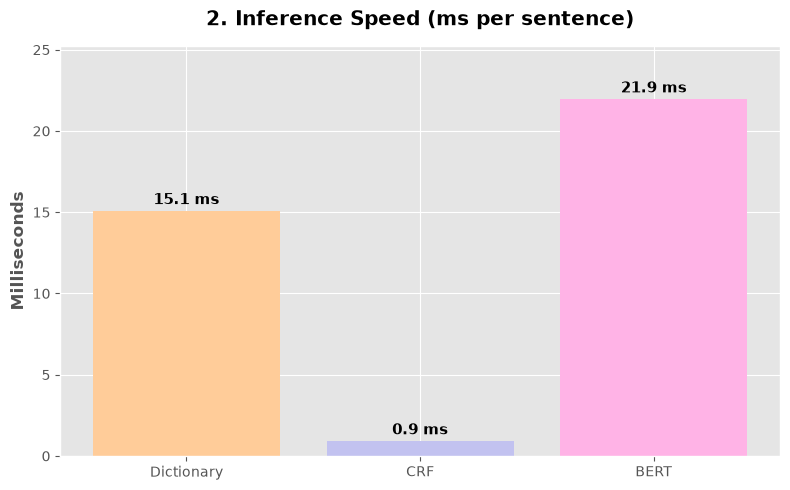

In [4]:
speeds = [speed_dict, speed_crf, speed_bert]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(models, speeds, color=['#ffcc99','#c2c2f0','#ffb3e6'])
ax.set_title('2. Inference Speed (ms per sentence)', fontweight='bold', pad=15)
ax.set_ylabel('Milliseconds', fontweight='bold')

max_speed = max(speeds)
ax.set_ylim(0, max_speed * 1.15)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (max_speed * 0.02), f"{yval:.1f} ms", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

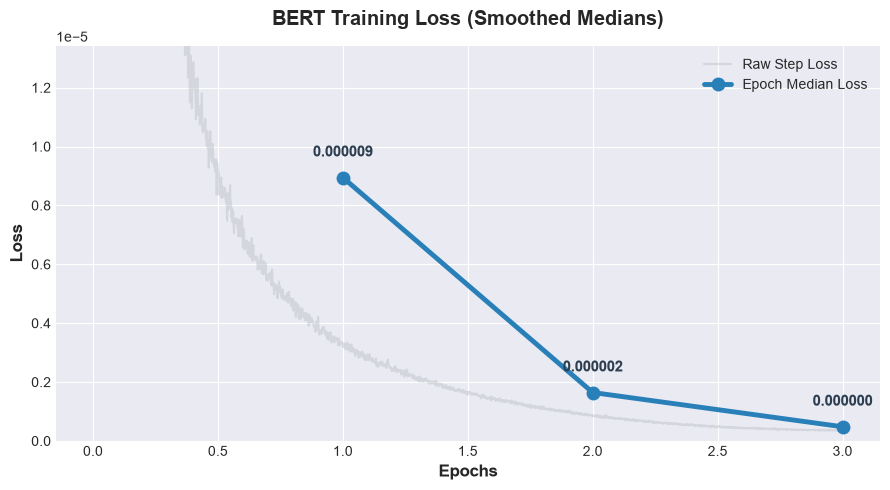

In [5]:
model_dir = Path(config['paths']['models_finetuned'])
checkpoints = list(model_dir.glob("checkpoint-*"))

if not checkpoints:
    print(f"Checkpoint folder not found in {model_dir}")
else:
    latest_checkpoint = sorted(checkpoints, key=lambda x: int(x.name.split("-")[1]))[-1]
    state_path = latest_checkpoint / "trainer_state.json"

    if state_path.exists():
        with open(state_path, "r", encoding="utf-8") as f:
            state = json.load(f)
        
        history = state.get("log_history", [])
        raw_epochs = [log["epoch"] for log in history if "loss" in log]
        raw_loss = [log["loss"] for log in history if "loss" in log]

        if not raw_loss:
            print("No 'loss' entries found.")
        else:
            epoch_bins = {}
            for ep, l in zip(raw_epochs, raw_loss):
                ep_int = max(1, math.ceil(ep)) 
                if ep_int not in epoch_bins:
                    epoch_bins[ep_int] = []
                epoch_bins[ep_int].append(l)

            med_epochs = sorted(epoch_bins.keys())
            med_losses = [np.median(epoch_bins[ep]) for ep in med_epochs]

            plt.style.use('seaborn-v0_8-darkgrid') 
            fig, ax = plt.subplots(figsize=(9, 5))

            ax.plot(raw_epochs, raw_loss, color='#bdc3c7', alpha=0.5, label='Raw Step Loss')
            
            ax.plot(med_epochs, med_losses, marker='o', linestyle='-', color='#2980b9', 
                    linewidth=3.5, markersize=9, label='Epoch Median Loss')
            
            ax.set_title('BERT Training Loss (Smoothed Medians)', fontweight='bold', pad=15)
            ax.set_xlabel('Epochs', fontweight='bold')
            ax.set_ylabel('Loss', fontweight='bold')
            
            ax.set_ylim(0, max(med_losses) * 1.5)
            
            for ep, l in zip(med_epochs, med_losses):
                ax.text(ep, l + (max(med_losses)*0.08), f"{l:.6f}", ha='center', color='#2c3e50', fontsize=11, fontweight='bold')

            ax.legend()
            plt.tight_layout()
            plt.show()
    else:
        print(f"File {state_path} not found.")

In [6]:
print("="*60)
print(f"EXAMPLE PREDICTION (Live Test)")
print(f"Text: '{test_text}'")
print("="*60)

print("\n[ DICTIONARY ]:")
dict_res = dict_model.predict(test_text)
dict_found = False
for token, label in zip(dict_res.get("tokens", []), dict_res.get("labels", [])):
    if label != "O":
        print(f"  {token:<12} {label}")
        dict_found = True
if not dict_found:
    print("  (No exact matches found)")

print("\n[ CRF MODEL ]:")
crf_res = crf_model.predict(test_text)
for token, label in zip(crf_res["tokens"], crf_res["labels"]):
    if label != "O":
        print(f"  {token:<12} {label}")

print("\n[ FINE-TUNED BERT ]:")
bert_res = bert_model.predict(test_text)
for entity in bert_res:
    print(f"  {entity.get('word', ''):<12} {entity.get('entity', '')} (Conf: {entity.get('score', 0):.4f})")
print("="*60)

EXAMPLE PREDICTION (Live Test)
Text: 'Last year I visited Nepal to see Mount Everest, but next time I want to conquer K2 and maybe a small hill near my house.'

[ DICTIONARY ]:
  Mount        B-MOUNTAIN
  Everest      I-MOUNTAIN
  K2           B-MOUNTAIN

[ CRF MODEL ]:
  Mount        B-MOUNTAIN
  Everest      I-MOUNTAIN

[ FINE-TUNED BERT ]:
  Mount         (Conf: 1.0000)
  K             (Conf: 1.0000)
  ##2           (Conf: 0.9446)
